# ORB: полный разбор от FAST до rBRIEF

Интерактивный ноутбук по материалам статей:

| Метод | Статья |
|---|---|
| **FAST** | Rosten, Drummond. *Machine learning for high-speed corner detection* (ECCV 2006) |
| **Harris** | Harris, Stephens. *A combined corner and edge detector* (1988) |
| **BRIEF** | Calonder et al. *BRIEF: Binary Robust Independent Elementary Features* (ECCV 2010) |
| **ORB** | Rublee et al. *ORB: an efficient alternative to SIFT or SURF* (ICCV 2011) |
| **SIFT** | Lowe. *Distinctive image features from scale-invariant keypoints* (IJCV 2004) |

**Что мы сделаем:**
1. Разберём каждый компонент ORB изнутри.
2. Реализуем FAST, Harris, BRIEF вручную.
3. Воспроизведём обучение rBRIEF.
4. Сравним ORB с SIFT по скорости и качеству.
5. Проведём эксперименты из статьи (поворот, шум).

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
from typing import List, Tuple, Optional

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['image.cmap'] = 'gray'
plt.rcParams['figure.dpi'] = 90

np.random.seed(42)

print('OpenCV:', cv2.__version__)
print('NumPy:', np.__version__)

OpenCV: 5.0.0
NumPy: 2.5.3


---
## 0. Утилиты и тестовые данные

Создаём синтетическую сцену, чтобы ноутбук работал без внешних файлов. Если у тебя есть свои изображения — замени `make_synthetic_scene()` на `cv2.imread(..., cv2.IMREAD_GRAYSCALE)`.

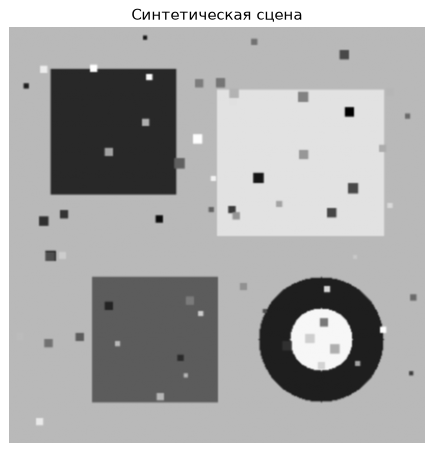

In [3]:
def make_synthetic_scene(size: int = 400, seed: int = 42) -> np.ndarray:
    """Синтетическая сцена с прямоугольниками, кругами и текстурами."""
    rng = np.random.default_rng(seed)
    img = np.full((size, size), 180, dtype=np.uint8)
    cv2.rectangle(img, (40, 40), (160, 160), 40, -1)
    cv2.rectangle(img, (200, 60), (360, 200), 220, -1)
    cv2.rectangle(img, (80, 240), (200, 360), 90, -1)
    cv2.circle(img, (300, 300), 60, 30, -1)
    cv2.circle(img, (300, 300), 30, 240, -1)
    for _ in range(60):
        x, y = rng.integers(0, size - 12, 2)
        s = rng.integers(3, 10)
        v = int(rng.integers(0, 255))
        cv2.rectangle(img, (x, y), (x + s, y + s), v, -1)
    return cv2.GaussianBlur(img, (3, 3), 0.8)


def rotate_image(img: np.ndarray, angle: float, scale: float = 1.0) -> np.ndarray:
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, scale)
    return cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR)


def add_gaussian_noise(img: np.ndarray, sigma: float) -> np.ndarray:
    noise = np.random.normal(0, sigma, img.shape).astype(np.float32)
    return np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)


img = make_synthetic_scene()
plt.imshow(img)
plt.title('Синтетическая сцена')
plt.axis('off')
plt.show()

---
## 1. FAST — детектор углов

### 1.1. Теория

FAST ищет точки, где на окружности радиуса 3 (16 пикселей) есть **9 подряд идущих** пикселей, все ярче или все темнее центрального.

**Ключевые идеи FAST:**
- **Segment test:** сравнение яркостей на окружности, а не градиенты.
- **High-speed test:** проверка 4 пикселей (1, 5, 9, 13) вместо 16 — отсев ~90% за 4 сравнения.
- **ID3-обучение:** дерево решений для оптимального порядка проверок (в ORB не используется).
- **Non-maximum suppression:** подавление соседних точек.

**Проблемы FAST:** нет score, нет ориентации, нет масштаба. ORB их решает.

In [23]:
# 16 точек на окружности радиуса 3 (порядок по часовой стрелке, начиная сверху)
CIRCLE_OFFSETS: List[Tuple[int, int]] = [
    (0, -3), (1, -3), (2, -2), (3, -1),
    (3, 0), (3, 1), (2, 2), (1, 3),
    (0, 3), (-1, 3), (-2, 2), (-3, 1),
    (-3, 0), (-3, -1), (-2, -2), (-1, -3),
]

# Индексы для high-speed test (пиксели 1, 5, 9, 13 → 0-based: 0, 4, 8, 12)
HIGHSPEED_INDICES = [0, 4, 8, 12]


def fast_segment_states(center: int, values: np.ndarray, threshold: int) -> np.ndarray:
    """Состояния 16 пикселей: +1 ярче, -1 темнее, 0 похож."""
    states = np.zeros(16, dtype=np.int8)
    states[values > center + threshold] = 1
    states[values < center - threshold] = -1
    return states


def has_n_consecutive(states: np.ndarray, n: int = 9) -> bool:
    """Есть ли n подряд идущих одинаковых ненулевых состояний (по кругу)?"""
    doubled = np.concatenate([states, states])
    for start in range(16):
        seg = doubled[start:start + n]
        if np.all(seg == 1) or np.all(seg == -1):
            return True
    return False


def fast_segment_test(img: np.ndarray, x: int, y: int,
                      threshold: int = 30, n: int = 9) -> bool:
    """Проверяет, является ли (x, y) FAST-углом."""
    h, w = img.shape
    if x < 3 or y < 3 or x >= w - 3 or y >= h - 3:
        return False
    center = int(img[y, x])
    values = np.array([int(img[y + dy, x + dx]) for dx, dy in CIRCLE_OFFSETS])
    states = fast_segment_states(center, values, threshold)
    return has_n_consecutive(states, n)


def fast_detect_manual(img: np.ndarray, threshold: int = 30, n: int = 9) -> List[Tuple[int, int]]:
    """Полный проход по изображению (медленно, для демонстрации)."""
    h, w = img.shape
    keypoints = []
    for y in range(3, h - 3):
        for x in range(3, w - 3):
            if fast_segment_test(img, x, y, threshold, n):
                keypoints.append((x, y))
    return keypoints

### 1.2. Визуализация FAST-окружности

Покажем, как выглядят состояния 16 пикселей для угла, края и плоской области.

In [24]:
def visualize_fast_circle_detailed(img: np.ndarray, x: int, y: int,
                                   threshold: int = 30, n: int = 9) -> bool:
    """Подробная визуализация FAST-теста для одной точки."""
    if x < 3 or y < 3 or x >= img.shape[1] - 3 or y >= img.shape[0] - 3:
        print(f'Точка ({x}, {y}) слишком близко к краю')
        return False

    center = int(img[y, x])
    values = np.array([int(img[y + dy, x + dx]) for dx, dy in CIRCLE_OFFSETS])
    states = fast_segment_states(center, values, threshold)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Левая панель
    ax = axes[0]
    ax.imshow(img, cmap='gray')
    color_map = {1: 'lime', -1: 'red', 0: 'yellow'}
    for i, ((dx, dy), s) in enumerate(zip(CIRCLE_OFFSETS, states)):
        ax.plot(x + dx, y + dy, 'o', color=color_map[s], markersize=12,
                markeredgecolor='black', markeredgewidth=1.2, zorder=5)
        ax.text(x + dx + 0.5, y + dy - 0.5, str(i + 1),
                fontsize=8, color='white', zorder=6)
    ax.plot(x, y, 's', color='cyan', markersize=12,
            markeredgecolor='black', markeredgewidth=1.2, zorder=5)
    ax.add_patch(plt.Circle((x, y), 3, color='blue', fill=False, linewidth=1.5, linestyle='--'))
    ax.set_xlim(x - 9, x + 9)
    ax.set_ylim(y + 9, y - 9)
    ax.set_title(f'Окружность FAST (центр={center}, порог={threshold})')

    # Правая панель
    ax = axes[1]
    label_map = {1: 'ярче', -1: 'темнее', 0: 'похож'}
    for i, s in enumerate(states):
        ax.bar(i, 1, bottom=-0.5, color=color_map[s], edgecolor='black')
        ax.text(i, 1.3, label_map[s], ha='center', fontsize=7)
    ax.set_xlim(-0.6, 15.6)
    ax.set_ylim(-0.6, 1.8)
    ax.set_xticks(range(16))
    ax.set_xticklabels([str(i + 1) for i in range(16)], fontsize=8)
    ax.set_yticks([])
    ax.set_xlabel('Позиция на окружности')

    # Поиск сегмента
    doubled = np.concatenate([states, states])
    found = False
    for start in range(16):
        seg = doubled[start:start + n]
        if np.all(seg == 1) or np.all(seg == -1):
            found = True
            for k in range(start, start + n):
                ax.bar(k % 16, 1, bottom=-0.5, color='none',
                       edgecolor='blue', linewidth=3)
            break

    title = f'✓ Угол! Найдено {n} подряд' if found else f'✗ Не угол'
    color = 'green' if found else 'red'
    ax.set_title(title, color=color, fontsize=13, fontweight='bold')

    plt.tight_layout()
    plt.show()
    return found

=== Угол (пересечение прямоугольника) (40, 40) ===


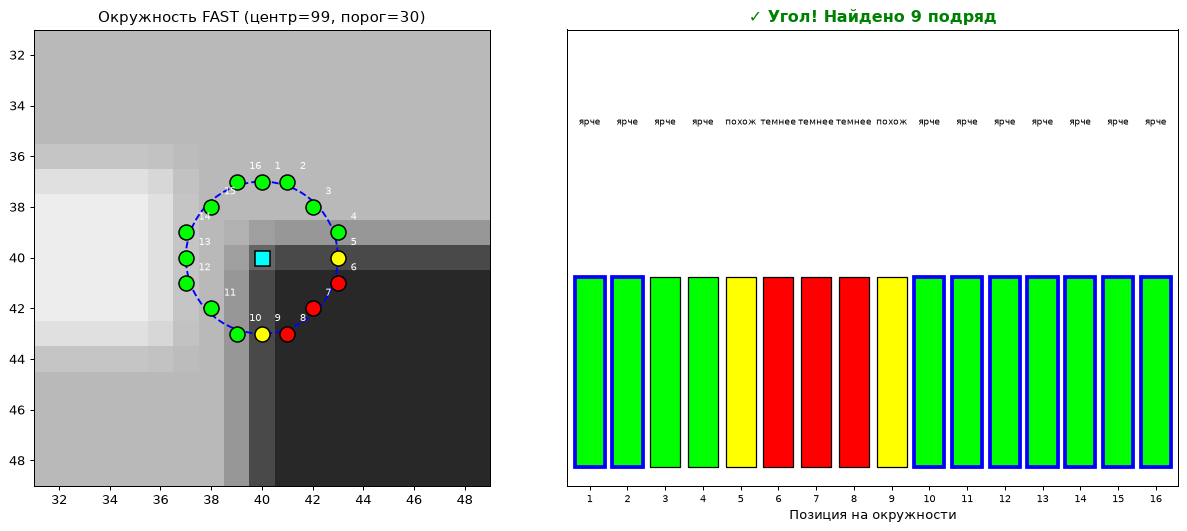

Результат: УГОЛ

=== Край (граница прямоугольника) (100, 40) ===


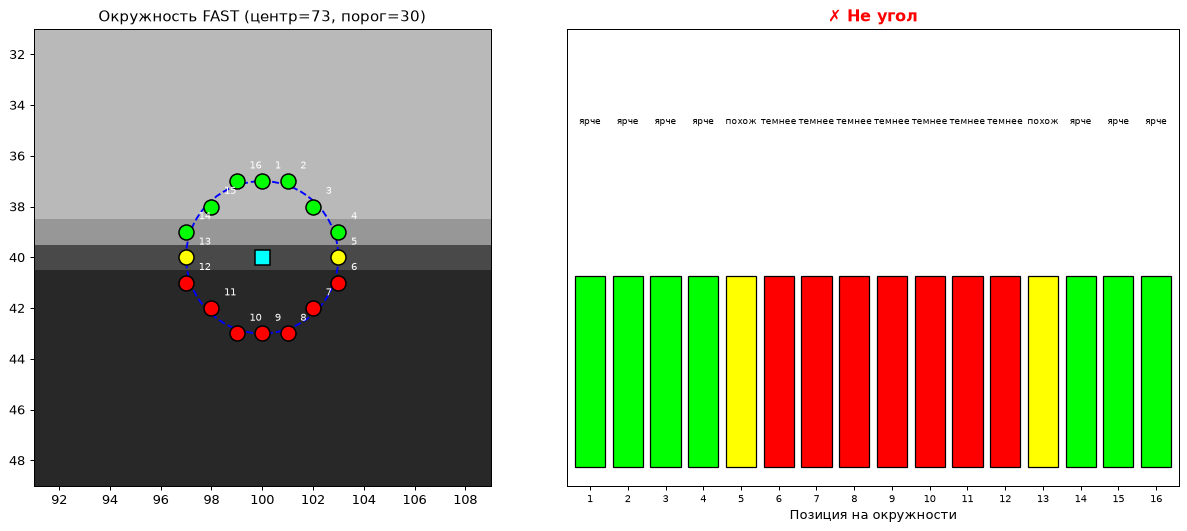

Результат: не угол

=== Плоскость (однородная область) (250, 250) ===


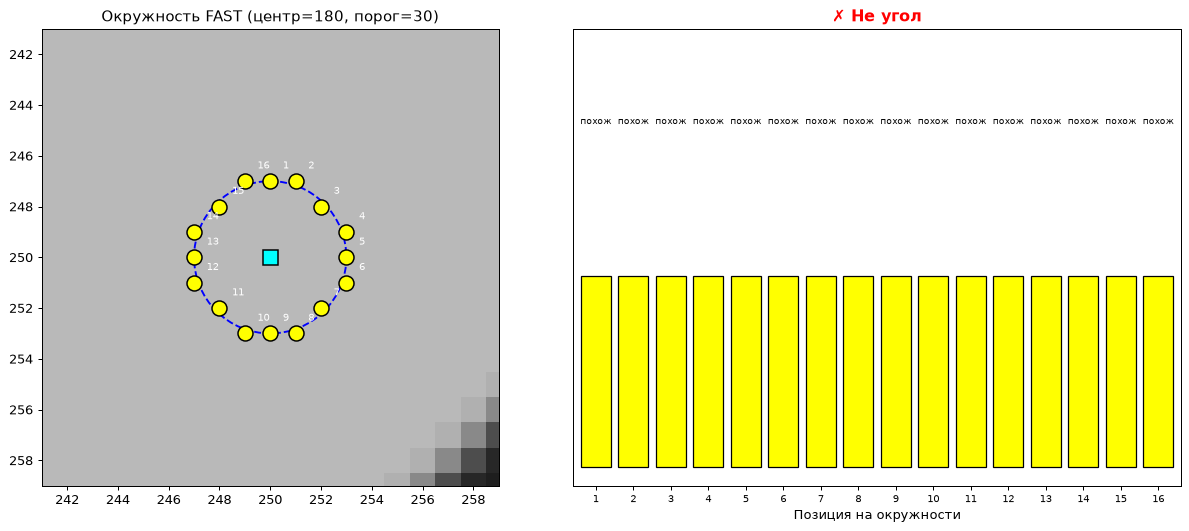

Результат: не угол



In [25]:
test_points = {
    'Угол (пересечение прямоугольника)': (40, 40),
    'Край (граница прямоугольника)':     (100, 40),
    'Плоскость (однородная область)':    (250, 250),
}

for name, (x, y) in test_points.items():
    print(f'=== {name} ({x}, {y}) ===')
    found = visualize_fast_circle_detailed(img, x, y, threshold=30, n=9)
    print(f'Результат: {"УГОЛ" if found else "не угол"}\n')

### 1.3. High-speed test: сколько пикселей отсеивается за 4 проверки

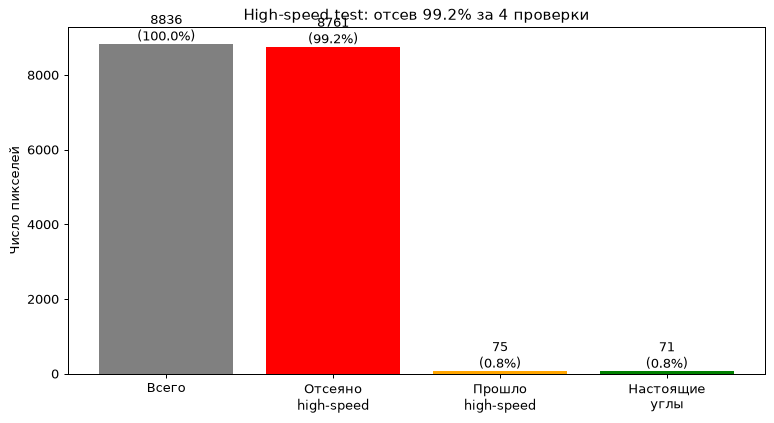

In [26]:
def fast_highspeed_stats(img: np.ndarray, threshold: int = 30, n: int = 9) -> dict:
    """Статистика: сколько пикселей отсеивается на этапе high-speed test."""
    h, w = img.shape
    total = 0
    rejected = 0
    passed = 0
    corners = 0

    for y in range(3, h - 3):
        for x in range(3, w - 3):
            total += 1
            center = int(img[y, x])
            values = np.array([int(img[y + dy, x + dx]) for dx, dy in CIRCLE_OFFSETS])
            states = fast_segment_states(center, values, threshold)

            # high-speed: сколько из 4 ключевых пикселей прошли
            hs = states[HIGHSPEED_INDICES]
            if np.sum(hs != 0) < 3:
                rejected += 1
                continue
            passed += 1
            if has_n_consecutive(states, n):
                corners += 1

    return {'total': total, 'rejected': rejected, 'passed': passed, 'corners': corners}


crop_small = img[100:200, 100:200]
stats = fast_highspeed_stats(crop_small, threshold=30)

fig, ax = plt.subplots(figsize=(10, 5))
labels = ['Всего', 'Отсеяно\nhigh-speed', 'Прошло\nhigh-speed', 'Настоящие\nуглы']
values = [stats['total'], stats['rejected'], stats['passed'], stats['corners']]
colors = ['gray', 'red', 'orange', 'green']
bars = ax.bar(labels, values, color=colors)
for b, v in zip(bars, values):
    pct = 100 * v / stats['total']
    ax.text(b.get_x() + b.get_width() / 2, v + stats['total'] * 0.01,
            f'{v}\n({pct:.1f}%)', ha='center', fontsize=10)
ax.set_ylabel('Число пикселей')
ax.set_title(f'High-speed test: отсев {100 * stats["rejected"] / stats["total"]:.1f}% за 4 проверки')
plt.show()

### 1.4. Сравнение ручного FAST и OpenCV

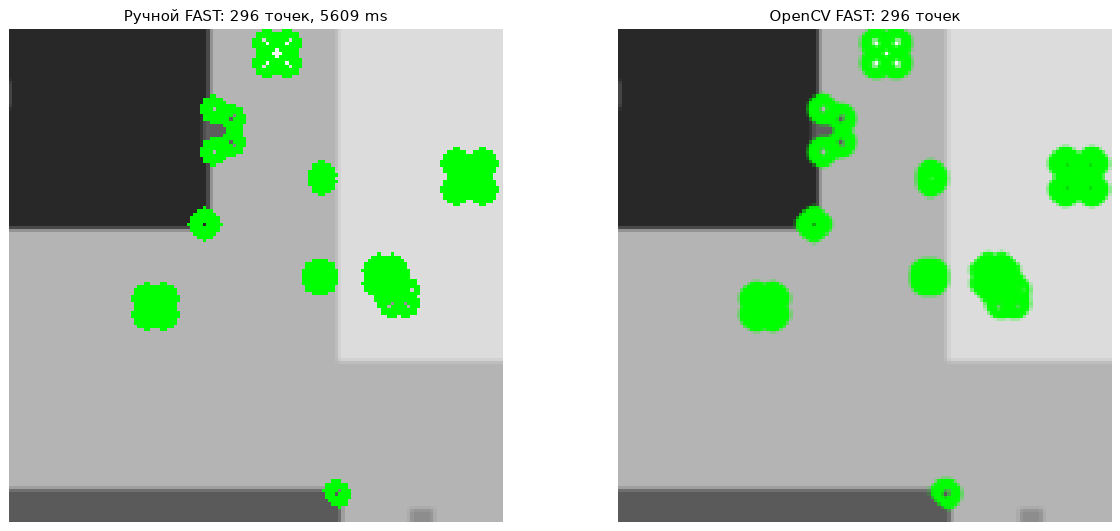

Ручной:        296
OpenCV:        296
Совпало:       296


In [27]:
crop = img[100:250, 100:250]

t0 = time.perf_counter()
kp_manual = fast_detect_manual(crop, threshold=30, n=9)
t_manual = (time.perf_counter() - t0) * 1000

fast_cv = cv2.FastFeatureDetector_create(threshold=30, nonmaxSuppression=False)
kp_cv_crop = fast_cv.detect(crop, None)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

vis_manual = cv2.cvtColor(crop, cv2.COLOR_GRAY2BGR)
for (x, y) in kp_manual:
    cv2.circle(vis_manual, (x, y), 3, (0, 255, 0), 1)
axes[0].imshow(cv2.cvtColor(vis_manual, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Ручной FAST: {len(kp_manual)} точек, {t_manual:.0f} ms')
axes[0].axis('off')

vis_cv = cv2.drawKeypoints(crop, kp_cv_crop, None, color=(0, 255, 0))
axes[1].imshow(vis_cv)
axes[1].set_title(f'OpenCV FAST: {len(kp_cv_crop)} точек')
axes[1].axis('off')
plt.tight_layout()
plt.show()

set_manual = set(kp_manual)
set_cv = set((int(kp.pt[0]), int(kp.pt[1])) for kp in kp_cv_crop)
print(f'Ручной:        {len(set_manual)}')
print(f'OpenCV:        {len(set_cv)}')
print(f'Совпало:       {len(set_manual & set_cv)}')

### 1.5. Влияние порога и N

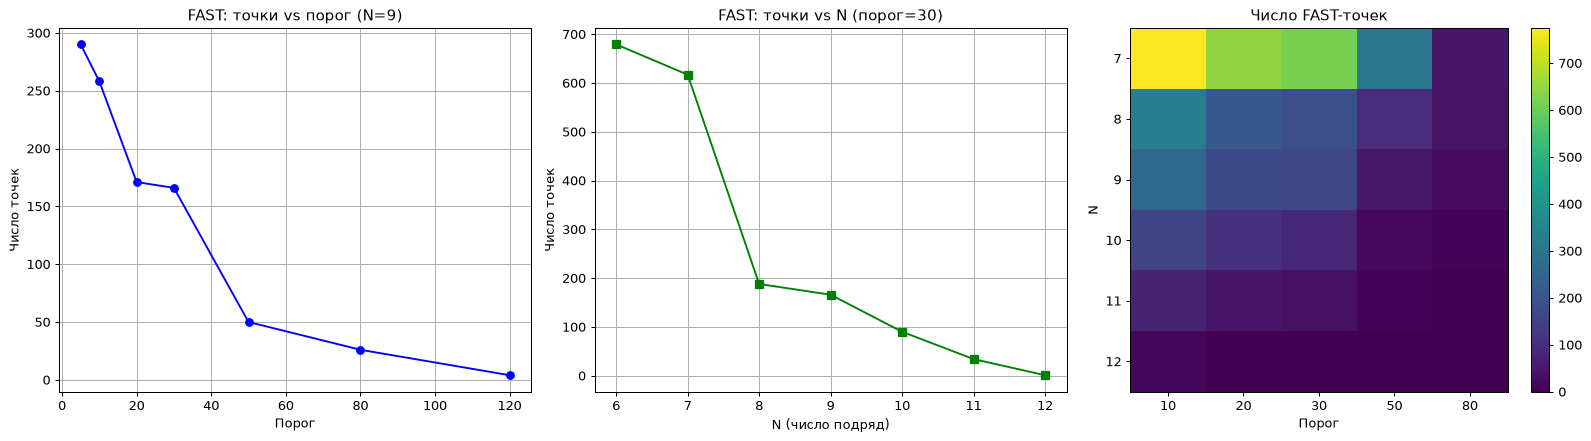

In [28]:
crop_small = img[100:200, 100:200]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. От порога
thresholds = [5, 10, 20, 30, 50, 80, 120]
counts_t = [len(fast_detect_manual(crop_small, t, 9)) for t in thresholds]
axes[0].plot(thresholds, counts_t, 'o-', color='blue')
axes[0].set_xlabel('Порог'); axes[0].set_ylabel('Число точек')
axes[0].set_title('FAST: точки vs порог (N=9)')
axes[0].grid(True)

# 2. От N
Ns = [6, 7, 8, 9, 10, 11, 12]
counts_n = [len(fast_detect_manual(crop_small, 30, n)) for n in Ns]
axes[1].plot(Ns, counts_n, 's-', color='green')
axes[1].set_xlabel('N (число подряд)'); axes[1].set_ylabel('Число точек')
axes[1].set_title('FAST: точки vs N (порог=30)')
axes[1].grid(True)

# 3. Тепловая карта
th_grid = [10, 20, 30, 50, 80]
n_grid = [7, 8, 9, 10, 11, 12]
heatmap = np.zeros((len(n_grid), len(th_grid)))
for i, n in enumerate(n_grid):
    for j, t in enumerate(th_grid):
        heatmap[i, j] = len(fast_detect_manual(crop_small, t, n))
im = axes[2].imshow(heatmap, cmap='viridis', aspect='auto')
axes[2].set_xticks(range(len(th_grid)))
axes[2].set_xticklabels([str(t) for t in th_grid])
axes[2].set_yticks(range(len(n_grid)))
axes[2].set_yticklabels([str(n) for n in n_grid])
axes[2].set_xlabel('Порог'); axes[2].set_ylabel('N')
axes[2].set_title('Число FAST-точек')
plt.colorbar(im, ax=axes[2])
plt.tight_layout()
plt.show()

---
## 2. Harris — фильтр углов

### 2.1. Теория

Матрица структурного тензора:
$$\mathbf{H} = \begin{bmatrix} \widehat{I_x^2} & \widehat{I_x I_y} \\ \widehat{I_x I_y} & \widehat{I_y^2} \end{bmatrix}$$

Отклик:
$$C = \det(\mathbf{H}) - k \cdot (\text{trace}(\mathbf{H}))^2$$

Собственные значения $\lambda_1, \lambda_2$:
- оба большие → угол,
- одно большое, другое ≈ 0 → край,
- оба маленькие → плоскость.

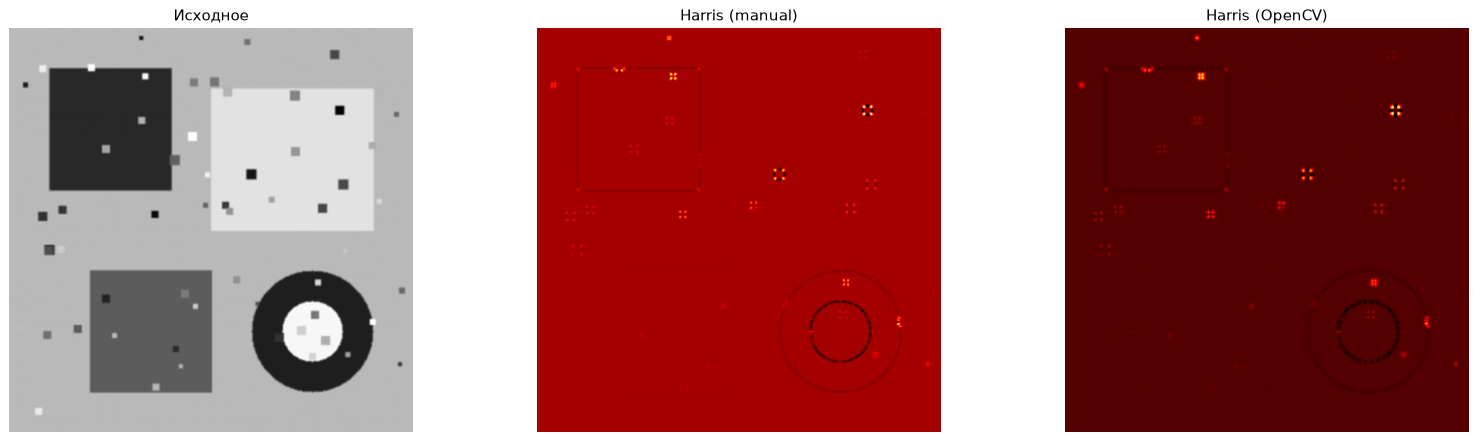

In [33]:
def harris_response_manual(img: np.ndarray, k: float = 0.04,
                           window_size: int = 5) -> np.ndarray:
    """Ручная реализация отклика Харриса."""
    img_f = img.astype(np.float32)
    Ix = cv2.Sobel(img_f, cv2.CV_32F, 1, 0, ksize=3)
    Iy = cv2.Sobel(img_f, cv2.CV_32F, 0, 1, ksize=3)

    Sxx = cv2.GaussianBlur(Ix * Ix, (window_size, window_size), 0)
    Syy = cv2.GaussianBlur(Iy * Iy, (window_size, window_size), 0)
    Sxy = cv2.GaussianBlur(Ix * Iy, (window_size, window_size), 0)

    det = Sxx * Syy - Sxy * Sxy
    trace = Sxx + Syy
    return det - k * trace * trace


R_manual = harris_response_manual(img)
R_cv = cv2.cornerHarris(img.astype(np.float32), blockSize=5, ksize=3, k=0.04)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(img); axes[0].set_title('Исходное'); axes[0].axis('off')
axes[1].imshow(R_manual, cmap='hot'); axes[1].set_title('Harris (manual)'); axes[1].axis('off')
axes[2].imshow(R_cv, cmap='hot'); axes[2].set_title('Harris (OpenCV)'); axes[2].axis('off')
plt.tight_layout()
plt.show()

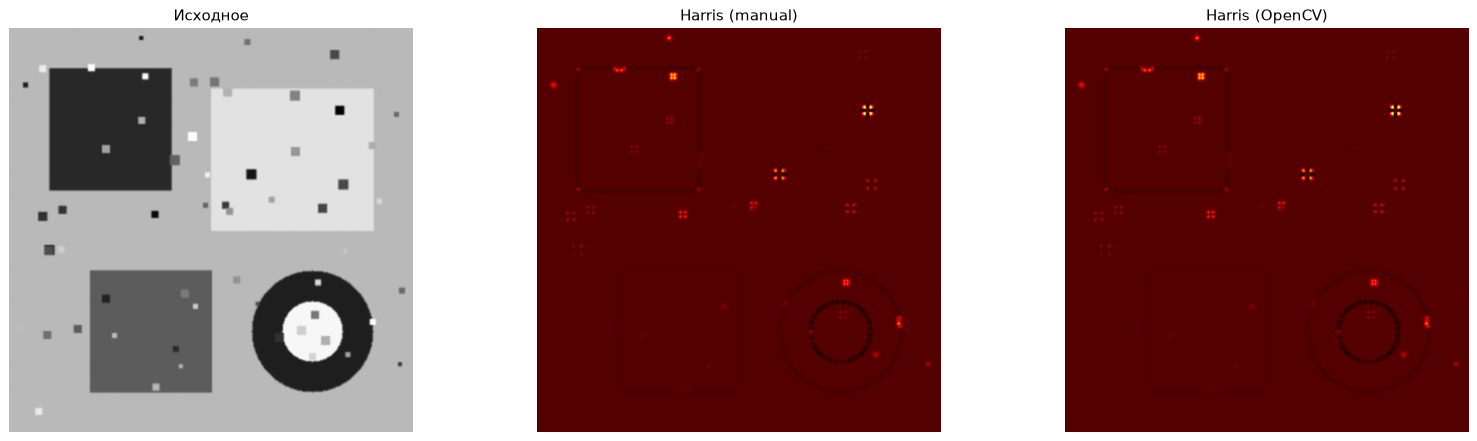

In [5]:
def harris_response_manual(img: np.ndarray, k: float = 0.04,
                           window_size: int = 5) -> np.ndarray:
    """Ручная реализация отклика Харриса (box-filter)."""
    img_f = img.astype(np.float32)
    Ix = cv2.Sobel(img_f, cv2.CV_32F, 1, 0, ksize=3)
    Iy = cv2.Sobel(img_f, cv2.CV_32F, 0, 1, ksize=3)

    Sxx = cv2.boxFilter(Ix * Ix, -1, (window_size, window_size))
    Syy = cv2.boxFilter(Iy * Iy, -1, (window_size, window_size))
    Sxy = cv2.boxFilter(Ix * Iy, -1, (window_size, window_size))

    det = Sxx * Syy - Sxy * Sxy
    trace = Sxx + Syy
    return det - k * trace * trace


R_manual = harris_response_manual(img)
R_cv = cv2.cornerHarris(img.astype(np.float32), blockSize=5, ksize=3, k=0.04)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(img); axes[0].set_title('Исходное'); axes[0].axis('off')
axes[1].imshow(R_manual, cmap='hot'); axes[1].set_title('Harris (manual)'); axes[1].axis('off')
axes[2].imshow(R_cv, cmap='hot'); axes[2].set_title('Harris (OpenCV)'); axes[2].axis('off')
plt.tight_layout()
plt.show()

### 2.2. Harris как фильтр для FAST

FAST даёт кандидатов, Harris используется для ранжирования и отсева краёв.

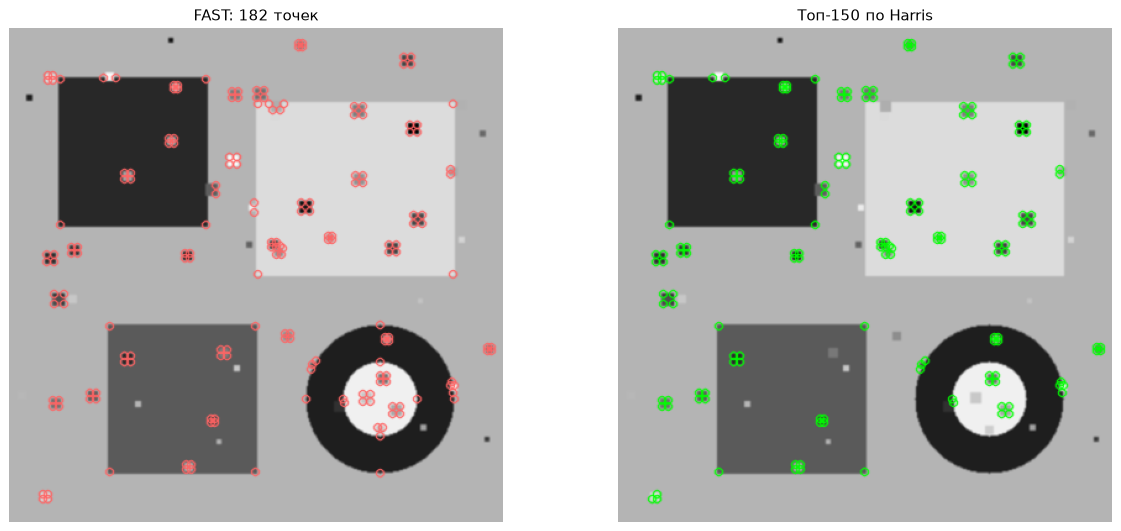

In [6]:
fast_full = cv2.FastFeatureDetector_create(threshold=20, nonmaxSuppression=True)
kp_fast = fast_full.detect(img, None)

R = harris_response_manual(img)
scores = np.array([R[int(kp.pt[1]), int(kp.pt[0])] for kp in kp_fast])

# Топ-200 по Harris
top_idx = np.argsort(scores)[::-1][:150]
top_kp = [kp_fast[i] for i in top_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(cv2.drawKeypoints(img, kp_fast, None, color=(255, 100, 100)))
axes[0].set_title(f'FAST: {len(kp_fast)} точек'); axes[0].axis('off')
axes[1].imshow(cv2.drawKeypoints(img, top_kp, None, color=(0, 255, 0)))
axes[1].set_title(f'Топ-150 по Harris'); axes[1].axis('off')
plt.tight_layout()
plt.show()

---
## 3. Intensity Centroid — ориентация

### 3.1. Теория

Моменты патча: $m_{pq} = \sum_{x,y} x^p y^q I(x,y)$

Центроид: $\mathbf{C} = (m_{10}/m_{00}, m_{01}/m_{00})$

Ориентация: $\theta = \text{atan2}(m_{01}, m_{10})$

Моменты считаются в **круговой** области для изотропии. Это дешевле и устойчивее к шуму, чем гистограммы градиентов.

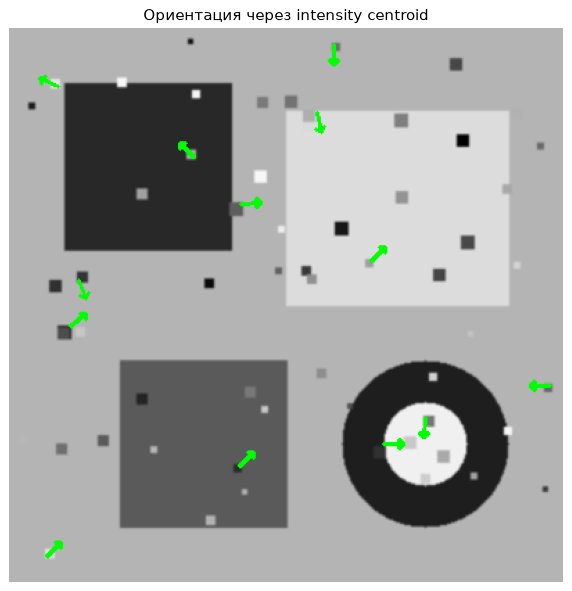

In [38]:
def intensity_centroid_orientation(img: np.ndarray, x: int, y: int,
                                   radius: int = 15) -> float:
    """Ориентация через центроид яркости в круговом окне."""
    h, w = img.shape
    x0, x1 = max(0, x - radius), min(w, x + radius + 1)
    y0, y1 = max(0, y - radius), min(h, y + radius + 1)

    yy, xx = np.mgrid[y0:y1, x0:x1]
    xx = xx - x
    yy = yy - y
    mask = (xx * xx + yy * yy) <= radius * radius
    I = img[y0:y1, x0:x1].astype(np.float32) * mask

    m00 = I.sum()
    if m00 < 1e-6:
        return 0.0
    m10 = (xx * I).sum()
    m01 = (yy * I).sum()
    return float(np.arctan2(m01, m10))


def draw_orientations(img: np.ndarray, keypoints: list,
                      radius: int = 15,
                      color: Tuple[int, int, int] = (0, 255, 0)) -> np.ndarray:
    vis = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    for kp in keypoints:
        x, y = int(kp.pt[0]), int(kp.pt[1])
        theta = intensity_centroid_orientation(img, x, y, radius)
        dx = int(radius * np.cos(theta))
        dy = int(radius * np.sin(theta))
        cv2.arrowedLine(vis, (x, y), (x + dx, y + dy), color, 2, tipLength=0.3)
    return vis


kp_subset = kp_fast[::15]
vis = draw_orientations(img, kp_subset, radius=15)
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title('Ориентация через intensity centroid')
plt.axis('off')
plt.show()

Исходная точка:           (200, 60)
После поворота на 30°:  (130, 79)

Ориентация на исходном:   +76.1°
Ориентация на повёрнутом: +46.2°
Разница:                  -29.8°
Ожидаемая разница:        -30.0° (из-за y-вниз)


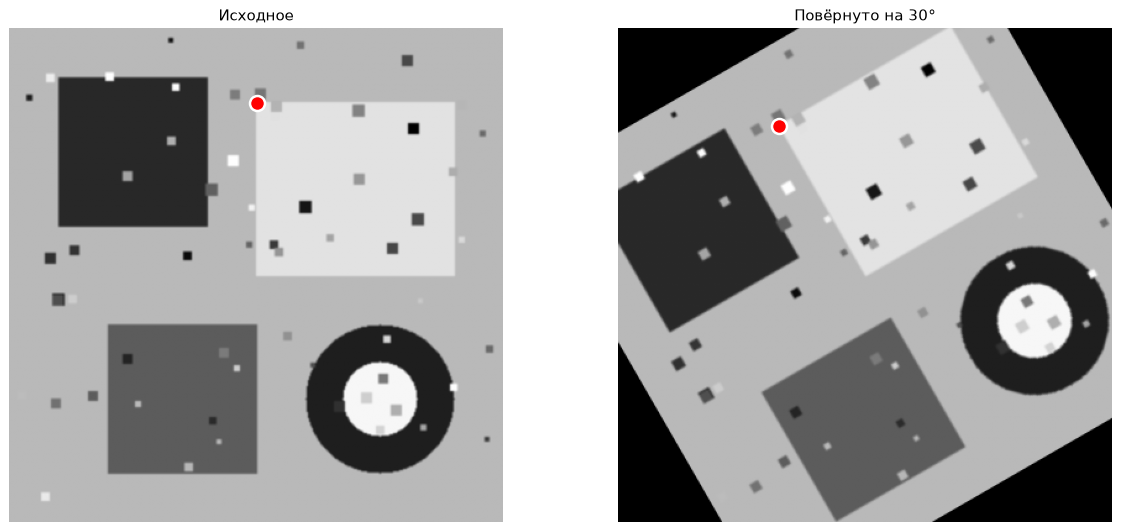

In [ ]:
# Проверка инвариантности к повороту
angle = 30
img_rot = rotate_image(img, angle)

# Возьмём точку, которая точно останется внутри после поворота
pt_orig = (200, 60)

# Вычисляем новые координаты через ту же матрицу поворота
h, w = img.shape
M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
pt_h = M @ np.array([pt_orig[0], pt_orig[1], 1.0])
x_rot, y_rot = int(round(pt_h[0])), int(round(pt_h[1]))

print(f'Исходная точка:           {pt_orig}')
print(f'После поворота на {angle}°:  ({x_rot}, {y_rot})')

# Проверка границ
assert 0 <= x_rot < w and 0 <= y_rot < h, \
    f'Точка ({x_rot}, {y_rot}) вышла за пределы {w}x{h}'

theta1 = np.degrees(intensity_centroid_orientation(img, pt_orig[0], pt_orig[1]))
theta2 = np.degrees(intensity_centroid_orientation(img_rot, x_rot, y_rot))

print()
print(f'Ориентация на исходном:   {theta1:+.1f}°')
print(f'Ориентация на повёрнутом: {theta2:+.1f}°')
print(f'Разница:                  {theta2 - theta1:+.1f}°')
print(f'Ожидаемая разница:        {-angle:+.1f}° (из-за y-вниз)')

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(img)
axes[0].plot(*pt_orig, 'ro', markersize=12, markeredgecolor='white', markeredgewidth=2)
axes[0].set_title('Исходное')
axes[0].axis('off')

axes[1].imshow(img_rot)
axes[1].plot(x_rot, y_rot, 'ro', markersize=12, markeredgecolor='white', markeredgewidth=2)
axes[1].set_title(f'Повёрнуто на {angle}°')
axes[1].axis('off')
plt.tight_layout()
plt.show()

---
## 4. BRIEF — бинарный дескриптор

### 4.1. Теория

Бинарный тест: $\tau(\mathbf{p}; \mathbf{x}, \mathbf{y}) = 1$, если $\mathbf{p}(\mathbf{x}) < \mathbf{p}(\mathbf{y})$, иначе 0.

Дескриптор: $f_{n_d}(\mathbf{p}) = \sum_i 2^{i-1} \tau_i$

В BRIEF: сглаженный патч $31\times31$, подокна $5\times5$, пары точек из гауссова распределения.

In [50]:
def sample_pairs_gaussian_gii(n_pairs: int = 256, patch_size: int = 31, seed: int = 42):
    """
    Пары точек по стратегии G II из статьи BRIEF.
    """
    rng = np.random.default_rng(seed)
    half = patch_size // 2                     # 15
    sigma = patch_size / 5.0                   # 6.2
    
    pts = rng.normal(0, sigma, size=(2 * n_pairs, 2))

    max_coord = half - 2                       # 13
    pts = np.clip(pts, -max_coord, max_coord)
    
    return pts[:n_pairs].astype(np.float32), pts[n_pairs:].astype(np.float32)


def brief_descriptor(img: np.ndarray, x: int, y: int,
                     pairs_a: np.ndarray, pairs_b: np.ndarray,
                     subwindow: int = 5) -> np.ndarray:
    """Быстрый BRIEF через cv2.getRectSubPix или интегральные суммы."""
    h, w = img.shape
    sw = subwindow // 2
    desc = np.zeros(len(pairs_a), dtype=np.uint8)

    for i, (a, b) in enumerate(zip(pairs_a, pairs_b)):
        ax, ay = int(x + a[0]), int(y + a[1])
        bx, by = int(x + b[0]), int(y + b[1])
        if not (sw <= ax < w - sw and sw <= ay < h - sw):
            continue
        if not (sw <= bx < w - sw and sw <= by < h - sw):
            continue
        va = img[ay - sw:ay + sw + 1, ax - sw:ax + sw + 1].mean()
        vb = img[by - sw:by + sw + 1, bx - sw:bx + sw + 1].mean()
        desc[i] = 1 if va < vb else 0
    return desc

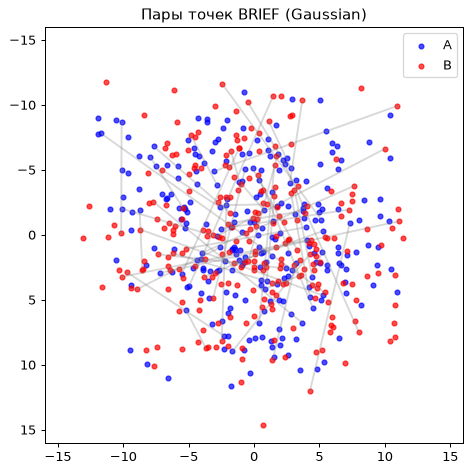

In [51]:
pairs_a, pairs_b = sample_pairs_gaussian(256, patch_size=31)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(pairs_a[:, 0], pairs_a[:, 1], c='blue', s=15, label='A', alpha=0.7)
ax.scatter(pairs_b[:, 0], pairs_b[:, 1], c='red', s=15, label='B', alpha=0.7)
for i in range(50):
    ax.plot([pairs_a[i, 0], pairs_b[i, 0]],
            [pairs_a[i, 1], pairs_b[i, 1]], 'gray', alpha=0.3)
ax.set_xlim(-16, 16); ax.set_ylim(16, -16)
ax.set_title('Пары точек BRIEF (Gaussian)'); ax.legend()
plt.show()

### 4.2. Статистика битов: среднее и дисперсия

Хороший BRIEF имеет средние значения битов около 0.5 (максимальная дисперсия).

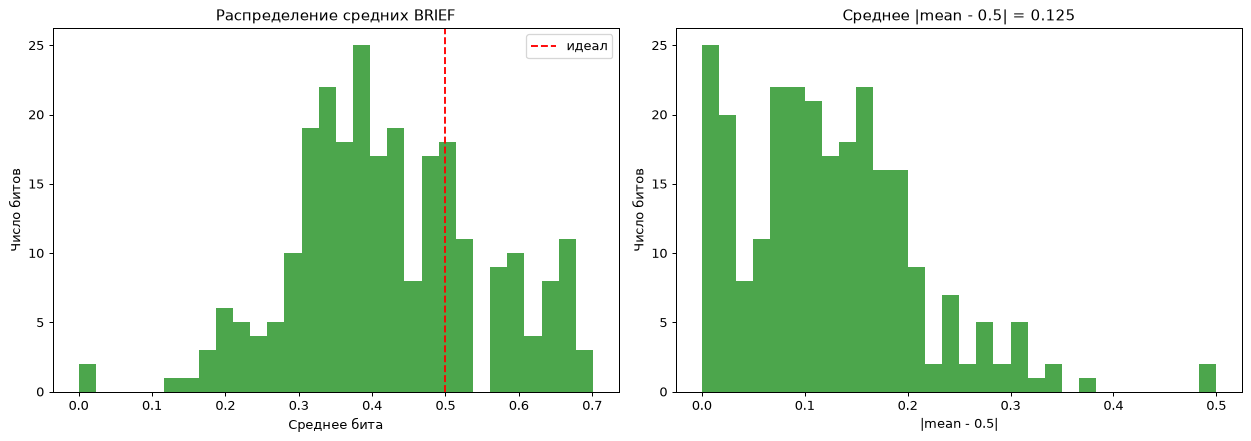

In [53]:
def collect_descriptors(img, keypoints, pairs_a, pairs_b, subwindow=5):
    """Собирает дескрипторы для всех валидных ключевых точек."""
    descs = []
    valid_kp = []
    for kp in keypoints:
        x, y = int(kp.pt[0]), int(kp.pt[1])
        if 16 < x < img.shape[1] - 16 and 16 < y < img.shape[0] - 16:
            d = brief_descriptor(img, x, y, pairs_a, pairs_b, subwindow)
            descs.append(d)
            valid_kp.append(kp)
    return np.array(descs), valid_kp


descs_brief, valid_kp = collect_descriptors(img, kp_fast, pairs_a, pairs_b)
means = descs_brief.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(means, bins=30, color='green', alpha=0.7)
axes[0].axvline(0.5, color='red', linestyle='--', label='идеал')
axes[0].set_xlabel('Среднее бита'); axes[0].set_ylabel('Число битов')
axes[0].set_title('Распределение средних BRIEF'); axes[0].legend()

axes[1].hist(np.abs(means - 0.5), bins=30, color='green', alpha=0.7)
axes[1].set_xlabel('|mean - 0.5|'); axes[1].set_ylabel('Число битов')
axes[1].set_title(f'Среднее |mean - 0.5| = {np.abs(means - 0.5).mean():.3f}')
plt.tight_layout()
plt.show()

---
## 5. Steered BRIEF и его проблема

Поворот пар точек вдоль ориентации ключевой точки.

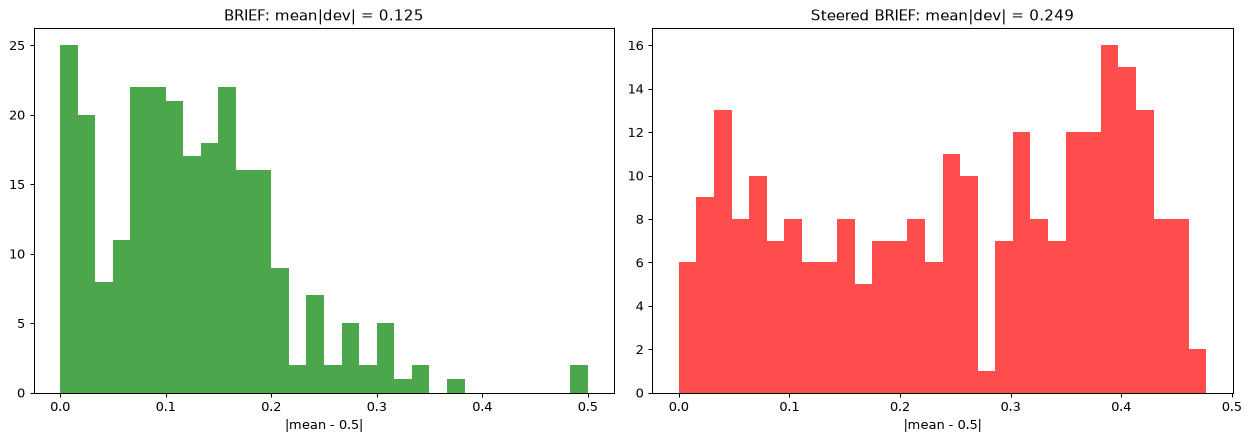

In [54]:
def rotate_pairs(pairs_a: np.ndarray, pairs_b: np.ndarray,
                 theta: float) -> Tuple[np.ndarray, np.ndarray]:
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, -s], [s, c]])
    return pairs_a @ R.T, pairs_b @ R.T


def collect_steered_descriptors(img, keypoints, pairs_a, pairs_b, subwindow=5):
    descs = []
    for kp in keypoints:
        x, y = int(kp.pt[0]), int(kp.pt[1])
        if 16 < x < img.shape[1] - 16 and 16 < y < img.shape[0] - 16:
            theta = intensity_centroid_orientation(img, x, y, radius=15)
            a_rot, b_rot = rotate_pairs(pairs_a, pairs_b, theta)
            d = brief_descriptor(img, x, y, a_rot, b_rot, subwindow)
            descs.append(d)
    return np.array(descs)


descs_steered = collect_steered_descriptors(img, kp_fast, pairs_a, pairs_b)
means_steered = descs_steered.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(np.abs(means - 0.5), bins=30, color='green', alpha=0.7)
axes[0].set_title(f'BRIEF: mean|dev| = {np.abs(means - 0.5).mean():.3f}')
axes[0].set_xlabel('|mean - 0.5|')
axes[1].hist(np.abs(means_steered - 0.5), bins=30, color='red', alpha=0.7)
axes[1].set_title(f'Steered BRIEF: mean|dev| = {np.abs(means_steered - 0.5).mean():.3f}')
axes[1].set_xlabel('|mean - 0.5|')
plt.tight_layout()
plt.show()

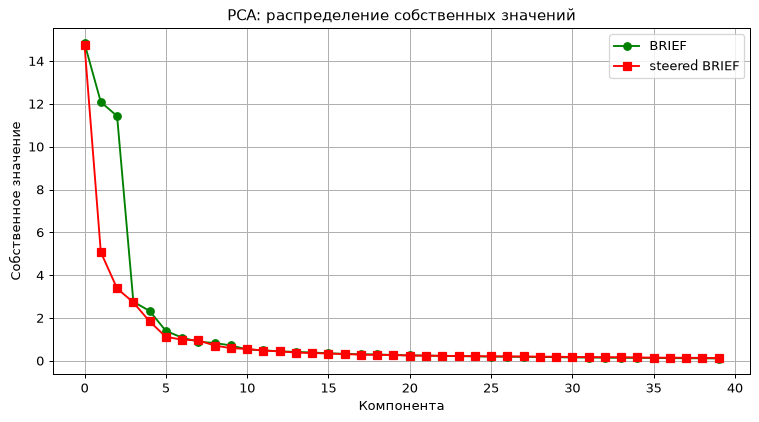

In [55]:
# PCA: собственные значения для BRIEF и steered BRIEF
def pca_eigenvalues(descs, n_components=40):
    centered = descs - descs.mean(axis=0)
    _, s, _ = np.linalg.svd(centered, full_matrices=False)
    return (s ** 2) / (s.shape[0] - 1)


ev_brief = pca_eigenvalues(descs_brief)
ev_steered = pca_eigenvalues(descs_steered)

plt.figure(figsize=(10, 5))
plt.plot(ev_brief[:40], 'o-', label='BRIEF', color='green')
plt.plot(ev_steered[:40], 's-', label='steered BRIEF', color='red')
plt.xlabel('Компонента'); plt.ylabel('Собственное значение')
plt.title('PCA: распределение собственных значений')
plt.legend(); plt.grid(True)
plt.show()

---
## 6. rBRIEF: обучение тестов

### 6.1. Теория

Жадный алгоритм:
1. Перебрать все пары подокон $5\times5$ в патче $31\times31$.
2. Отсортировать по $|mean - 0.5|$.
3. Жадно добавлять тесты, отбрасывая коррелированные.

### 6.2. Упрощённая реализация

Мы уменьшим число кандидатов для скорости (на реальном обучении их 205 590).

In [56]:
def generate_test_candidates(patch_size: int = 31, subwindow: int = 5,
                             step: int = 3) -> np.ndarray:
    """Все возможные пары подокон (без пересечений). step>1 для скорости."""
    half = patch_size // 2
    sw = subwindow // 2
    positions = []
    for y in range(-half + sw, half - sw + 1, step):
        for x in range(-half + sw, half - sw + 1, step):
            positions.append((x, y))
    positions = np.array(positions)

    candidates = []
    for i in range(len(positions)):
        for j in range(i + 1, len(positions)):
            if abs(positions[i][0] - positions[j][0]) <= subwindow and \
               abs(positions[i][1] - positions[j][1]) <= subwindow:
                continue
            candidates.append((positions[i], positions[j]))
    return np.array(candidates)


def compute_test_responses(img, keypoints, candidates,
                           subwindow: int = 5) -> np.ndarray:
    """Ответы всех тестов для всех ключевых точек. Векторизовано по тестам."""
    h, w = img.shape
    sw = subwindow // 2

    # Фильтруем точки слишком близко к краю
    valid = [(int(kp.pt[0]), int(kp.pt[1])) for kp in keypoints
             if 16 < int(kp.pt[0]) < w - 16 and 16 < int(kp.pt[1]) < h - 16]

    responses = np.zeros((len(valid), len(candidates)), dtype=np.uint8)

    for kp_i, (x, y) in enumerate(valid):
        # для каждой пары считаем разницу средних
        for c_i, (a, b) in enumerate(candidates):
            ax, ay = x + a[0], y + a[1]
            bx, by = x + b[0], y + b[1]
            va = img[ay - sw:ay + sw + 1, ax - sw:ax + sw + 1].mean()
            vb = img[by - sw:by + sw + 1, bx - sw:bx + sw + 1].mean()
            responses[kp_i, c_i] = 1 if va < vb else 0

    return responses

In [57]:
candidates = generate_test_candidates(patch_size=31, subwindow=5, step=3)
print(f'Кандидатов: {len(candidates)}')

# Ограничим для скорости
rng = np.random.default_rng(0)
subset_idx = rng.choice(len(candidates), size=min(3000, len(candidates)), replace=False)
candidates_sub = candidates[subset_idx]

print('Считаем ответы тестов...')
t0 = time.perf_counter()
responses = compute_test_responses(img, kp_fast, candidates_sub)
print(f'Готово за {time.perf_counter() - t0:.1f} сек. Форма: {responses.shape}')

Кандидатов: 2968
Считаем ответы тестов...
Готово за 20.3 сек. Форма: (174, 2968)


In [58]:
def greedy_select_tests(responses: np.ndarray, n_tests: int = 256,
                        corr_threshold: float = 0.4) -> List[int]:
    """Жадный отбор некоррелированных тестов с высоким |mean - 0.5|."""
    means = responses.mean(axis=0)
    order = np.argsort(np.abs(means - 0.5))

    selected: List[int] = []
    for idx in order:
        if len(selected) >= n_tests:
            break
        if not selected:
            selected.append(idx)
            continue

        r = responses[:, idx]
        if r.std() < 1e-6:
            continue

        max_corr = 0.0
        for s in selected:
            q = responses[:, s]
            if q.std() < 1e-6:
                continue
            c = abs(np.corrcoef(r, q)[0, 1])
            if c > max_corr:
                max_corr = c
        if max_corr < corr_threshold:
            selected.append(idx)
    return selected


selected = greedy_select_tests(responses, n_tests=256, corr_threshold=0.4)
print(f'Отобрано тестов: {len(selected)}')

rBRIEF_a = np.array([candidates_sub[i][0] for i in selected])
rBRIEF_b = np.array([candidates_sub[i][1] for i in selected])
print(f'Форма пар rBRIEF: {rBRIEF_a.shape}')

Отобрано тестов: 28
Форма пар rBRIEF: (28, 2)


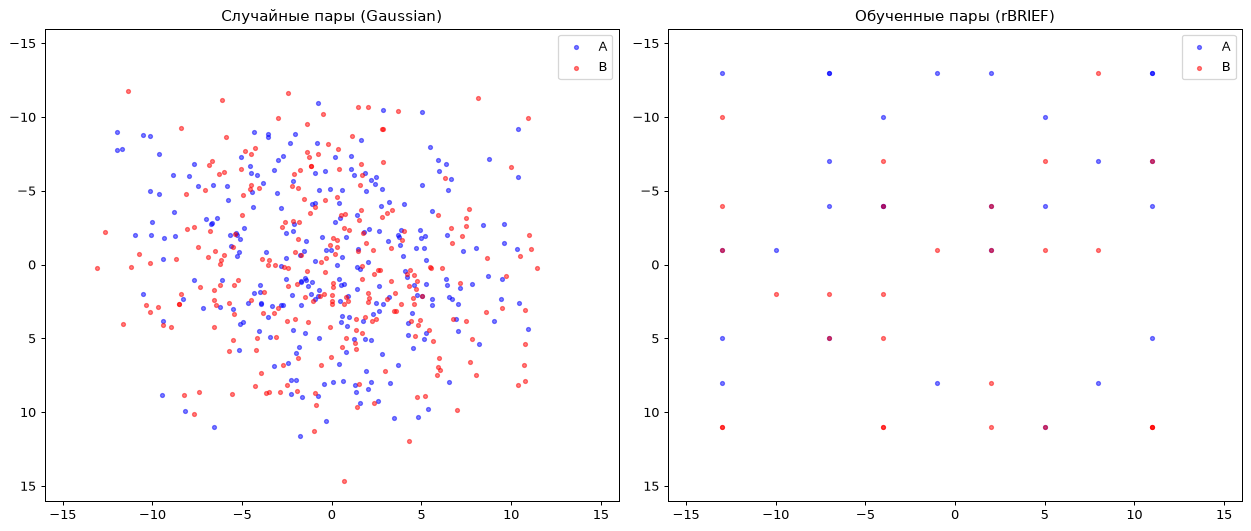

In [59]:
# Визуализация: случайные vs обученные пары
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(pairs_a[:, 0], pairs_a[:, 1], c='blue', s=10, alpha=0.5, label='A')
axes[0].scatter(pairs_b[:, 0], pairs_b[:, 1], c='red', s=10, alpha=0.5, label='B')
axes[0].set_xlim(-16, 16); axes[0].set_ylim(16, -16)
axes[0].set_title('Случайные пары (Gaussian)'); axes[0].legend()

axes[1].scatter(rBRIEF_a[:, 0], rBRIEF_a[:, 1], c='blue', s=10, alpha=0.5, label='A')
axes[1].scatter(rBRIEF_b[:, 0], rBRIEF_b[:, 1], c='red', s=10, alpha=0.5, label='B')
axes[1].set_xlim(-16, 16); axes[1].set_ylim(16, -16)
axes[1].set_title('Обученные пары (rBRIEF)'); axes[1].legend()
plt.tight_layout()
plt.show()

---
## 7. Полный конвейер ORB в OpenCV

### 7.1. ORB vs SIFT: скорость и дескрипторы

In [60]:
orb = cv2.ORB_create(nfeatures=500, scoreType=cv2.ORB_HARRIS_SCORE)
sift = cv2.SIFT_create(nfeatures=500)

t0 = time.perf_counter()
kp_orb, des_orb = orb.detectAndCompute(img, None)
t_orb = (time.perf_counter() - t0) * 1000

t0 = time.perf_counter()
kp_sift, des_sift = sift.detectAndCompute(img, None)
t_sift = (time.perf_counter() - t0) * 1000

print(f'ORB:  {len(kp_orb)} kp, {t_orb:6.1f} ms, дескриптор {des_orb.shape} {des_orb.dtype}')
print(f'SIFT: {len(kp_sift)} kp, {t_sift:6.1f} ms, дескриптор {des_sift.shape} {des_sift.dtype}')

ORB:  472 kp,  110.1 ms, дескриптор (472, 32) uint8
SIFT: 266 kp,  277.3 ms, дескриптор (266, 128) float32


### 7.2. Матчинг: Hamming vs L2

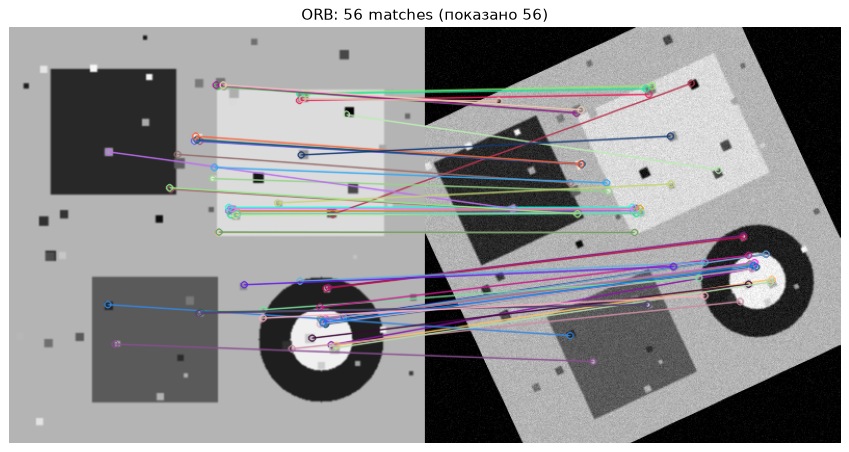

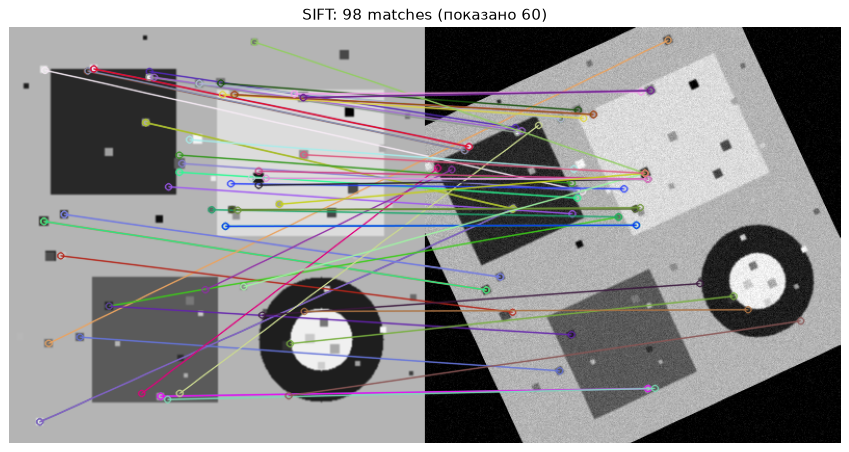

In [61]:
img2 = rotate_image(img, 25, scale=0.9)
img2 = add_gaussian_noise(img2, 8)


def match_and_draw(detector, norm, img1, img2, title, ratio=0.75, max_draw=60):
    kp1, des1 = detector.detectAndCompute(img1, None)
    kp2, des2 = detector.detectAndCompute(img2, None)
    if des1 is None or des2 is None:
        print(f'{title}: дескрипторы не найдены')
        return [], None, None

    bf = cv2.BFMatcher(norm)
    matches = bf.knnMatch(des1, des2, k=2)
    good = [m for m, n in matches if m.distance < ratio * n.distance]

    vis = cv2.drawMatches(img1, kp1, img2, kp2, good[:max_draw], None, flags=2)
    plt.figure(figsize=(14, 6))
    plt.imshow(vis); plt.title(f'{title}: {len(good)} matches (показано {min(len(good), max_draw)})')
    plt.axis('off'); plt.show()
    return good, kp1, kp2


good_orb, kp1_orb, kp2_orb = match_and_draw(orb, cv2.NORM_HAMMING, img, img2, 'ORB')
good_sift, kp1_sift, kp2_sift = match_and_draw(sift, cv2.NORM_L2, img, img2, 'SIFT')

### 7.3. RANSAC + гомография

ORB: всего matches=56, inliers=50


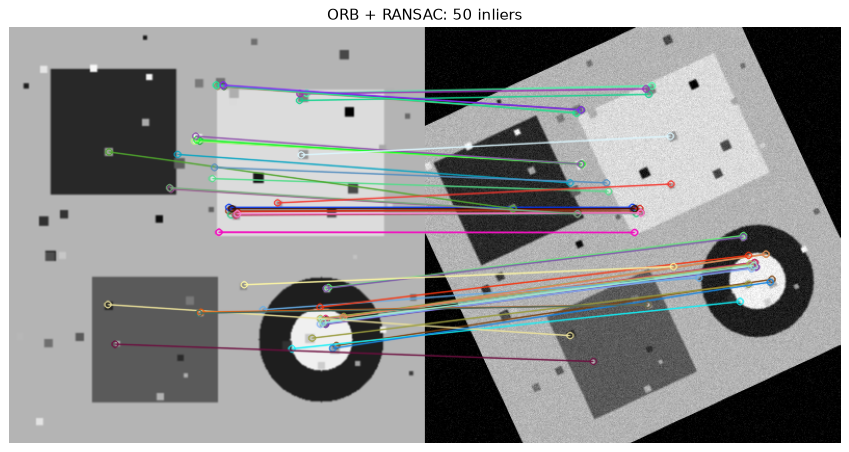

In [62]:
def ransac_homography(kp1, kp2, matches, thresh=5.0):
    if len(matches) < 4:
        return None, None, 0
    src = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
    dst = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)
    H, mask = cv2.findHomography(src, dst, cv2.RANSAC, thresh)
    inliers = int(mask.sum()) if mask is not None else 0
    return H, mask, inliers


H, mask, inliers = ransac_homography(kp1_orb, kp2_orb, good_orb)
print(f'ORB: всего matches={len(good_orb)}, inliers={inliers}')

if mask is not None:
    inlier_matches = [m for m, inl in zip(good_orb, mask.ravel()) if inl]
    vis = cv2.drawMatches(img, kp1_orb, img2, kp2_orb, inlier_matches[:60], None, flags=2)
    plt.figure(figsize=(14, 6))
    plt.imshow(vis); plt.title(f'ORB + RANSAC: {inliers} inliers')
    plt.axis('off'); plt.show()

---
## 8. Эксперименты

### 8.1. Инвариантность к повороту

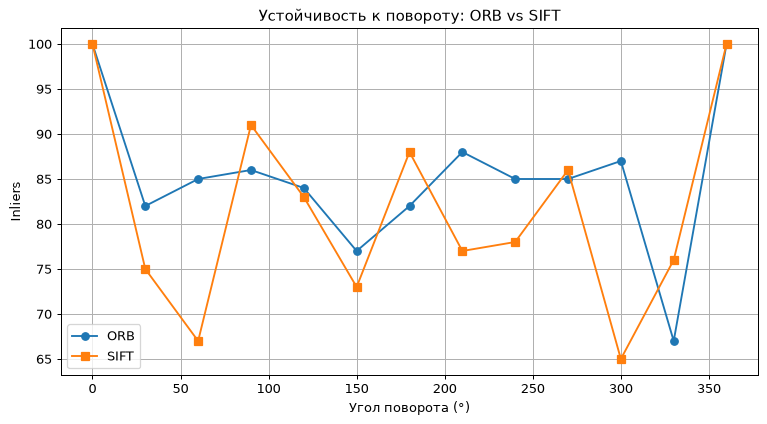

In [83]:
def evaluate_rotation(detector, norm, base_img, angles):
    results = []
    kp1, des1 = detector.detectAndCompute(base_img, None)
    if des1 is None:
        return [(a, 0, 0) for a in angles]

    for angle in angles:
        rotated = rotate_image(base_img, angle)
        kp2, des2 = detector.detectAndCompute(rotated, None)
        if des2 is None:
            results.append((angle, 0, 0))
            continue

        bf = cv2.BFMatcher(norm)
        knn = bf.knnMatch(des1, des2, k=2)
        good = [m for m, n in knn if m.distance < 0.75 * n.distance]
        good = sorted(good, key=lambda m: m.distance)[:100]

        _, _, inliers = ransac_homography(kp1, kp2, good)
        results.append((angle, len(good), inliers))
    return results


angles = list(range(0, 361, 30))
res_orb = evaluate_rotation(orb, cv2.NORM_HAMMING, img, angles)
res_sift = evaluate_rotation(sift, cv2.NORM_L2, img, angles)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot([r[0] for r in res_orb], [r[2] for r in res_orb], 'o-', label='ORB')
ax.plot([r[0] for r in res_sift], [r[2] for r in res_sift], 's-', label='SIFT')
ax.set_xlabel('Угол поворота (°)'); ax.set_ylabel('Inliers')
ax.set_title('Устойчивость к повороту: ORB vs SIFT')
ax.legend(); ax.grid(True)
plt.show()

### 8.2. Устойчивость к шуму

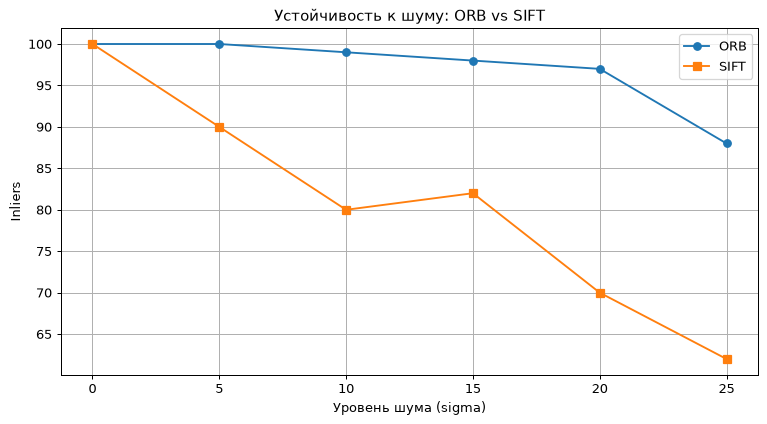

In [84]:
def evaluate_noise(detector, norm, base_img, sigmas):
    results = []
    kp1, des1 = detector.detectAndCompute(base_img, None)
    if des1 is None:
        return [(s, 0) for s in sigmas]

    for sigma in sigmas:
        noisy = add_gaussian_noise(base_img, sigma)
        kp2, des2 = detector.detectAndCompute(noisy, None)
        if des2 is None:
            results.append((sigma, 0))
            continue

        bf = cv2.BFMatcher(norm)
        knn = bf.knnMatch(des1, des2, k=2)
        good = [m for m, n in knn if m.distance < 0.75 * n.distance]
        good = sorted(good, key=lambda m: m.distance)[:100]
        _, _, inliers = ransac_homography(kp1, kp2, good)
        results.append((sigma, inliers))
    return results


sigmas = [0, 5, 10, 15, 20, 25]
res_orb_n = evaluate_noise(orb, cv2.NORM_HAMMING, img, sigmas)
res_sift_n = evaluate_noise(sift, cv2.NORM_L2, img, sigmas)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot([r[0] for r in res_orb_n], [r[1] for r in res_orb_n], 'o-', label='ORB')
ax.plot([r[0] for r in res_sift_n], [r[1] for r in res_sift_n], 's-', label='SIFT')
ax.set_xlabel('Уровень шума (sigma)'); ax.set_ylabel('Inliers')
ax.set_title('Устойчивость к шуму: ORB vs SIFT')
ax.legend(); ax.grid(True)
plt.show()

---
## 9. Бенчмарки скорости

In [86]:
def benchmark(detector, img, n_runs=10):
    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        detector.detectAndCompute(img, None)
        times.append((time.perf_counter() - t0) * 1000)
    return float(np.mean(times)), float(np.std(times))


detectors = {
    'ORB (Harris)': cv2.ORB_create(500, scoreType=cv2.ORB_HARRIS_SCORE),
    'ORB (FAST)':   cv2.ORB_create(500, scoreType=cv2.ORB_FAST_SCORE),
    'SIFT':         cv2.SIFT_create(500),
}

if hasattr(cv2, 'xfeatures2d'):
    if hasattr(cv2.xfeatures2d, 'BRISK_create'):
        detectors['BRISK'] = cv2.xfeatures2d.BRISK_create()
    if hasattr(cv2.xfeatures2d, 'AKAZE_create'):
        detectors['AKAZE'] = cv2.xfeatures2d.AKAZE_create()
else:
    print("Модуль 'xfeatures2d' не найден. Пропускаем BRISK и AKAZE.")

results = {}
for name, det in detectors.items():
    m, s = benchmark(det, img)
    results[name] = (m, s)
    print(f'{name:15s}: {m:7.2f} ± {s:5.2f} ms')

ORB (Harris)   :   10.77 ±  2.08 ms
ORB (FAST)     :   12.03 ±  2.76 ms
SIFT           :   84.96 ± 15.07 ms
BRISK          :   19.35 ±  6.54 ms
AKAZE          :   71.66 ± 14.34 ms


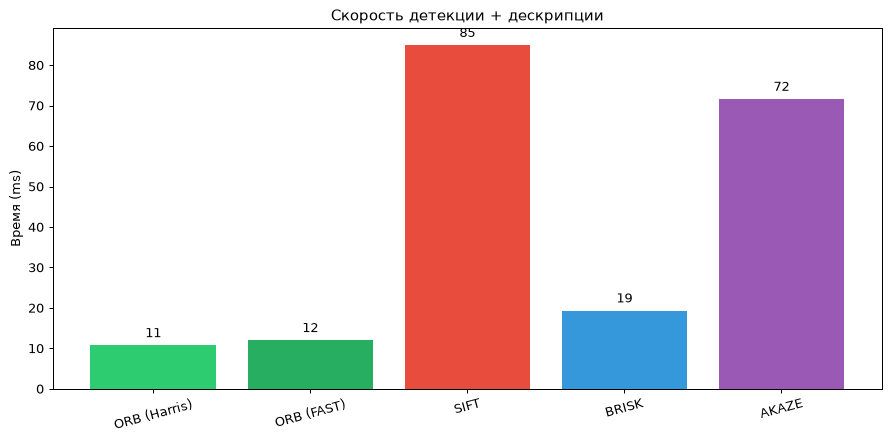

In [87]:
names = list(results.keys())
means = [results[n][0] for n in names]

plt.figure(figsize=(10, 5))
colors = ['#2ecc71', '#27ae60', '#e74c3c', '#3498db', '#9b59b6']
bars = plt.bar(names, means, color=colors)
plt.ylabel('Время (ms)'); plt.title('Скорость детекции + дескрипции')
plt.xticks(rotation=15)
for b, m in zip(bars, means):
    plt.text(b.get_x() + b.get_width() / 2, m + 2, f'{m:.0f}', ha='center')
plt.tight_layout()
plt.show()

---
## 10. Практические грабли

### 10.1. Параметры ORB

In [88]:
params = {
    'nfeatures': [100, 500, 1000],
    'scaleFactor': [1.1, 1.2, 1.5],
    'nlevels': [4, 8, 12],
    'fastThreshold': [10, 20, 30, 50],
    'patchSize': [15, 31, 47],
}

for param, values in params.items():
    print(f'\n=== {param} ===')
    for v in values:
        kwargs = {param: v}
        det = cv2.ORB_create(**kwargs)
        kp, des = det.detectAndCompute(img, None)
        print(f'  {param}={v}: {len(kp)} kp')


=== nfeatures ===
  nfeatures=100: 100 kp
  nfeatures=500: 472 kp
  nfeatures=1000: 653 kp

=== scaleFactor ===
  scaleFactor=1.1: 500 kp
  scaleFactor=1.2: 472 kp
  scaleFactor=1.5: 333 kp

=== nlevels ===
  nlevels=4: 499 kp
  nlevels=8: 472 kp
  nlevels=12: 432 kp

=== fastThreshold ===
  fastThreshold=10: 481 kp
  fastThreshold=20: 472 kp
  fastThreshold=30: 462 kp
  fastThreshold=50: 409 kp

=== patchSize ===
  patchSize=15: 472 kp
  patchSize=31: 472 kp
  patchSize=47: 472 kp


### 10.2. Когда ORB работает плохо

- Сильные аффинные искажения (наклон под углом).
- Малотекстурные сцены (стены, небо).
- Повторяющиеся паттерны (решётки, окна).
- Очень большие изменения масштаба (>2×).

---
## 11. Итоги

### Что мы разобрали

| Компонент | Что делает |
|---|---|
| **FAST** | Быстрый детектор углов через segment test |
| **High-speed test** | Проверка 4 пикселей вместо 16 |
| **Harris** | Мера угловатости, отсев краёв |
| **Intensity centroid** | Ориентация через моменты яркости |
| **BRIEF** | Бинарный дескриптор (256 бит) |
| **Steered BRIEF** | Поворот пар точек вдоль ориентации |
| **rBRIEF** | Обученный набор некоррелированных тестов |
| **ORB** | oFAST + rBRIEF |

### Ключевые выводы

1. **ORB = oFAST + rBRIEF** — комбинация с доработками.
2. **oFAST = FAST + Harris + orientation + pyramid**.
3. **rBRIEF = steered BRIEF + learning**.
4. **Hamming distance + popcount** — мгновенный матчинг.
5. **ORB на два порядка быстрее SIFT**, но не SOTA на 2026.

### Что дальше

- Попробовать на своих изображениях.
- Сравнить с learned features (SuperPoint, DISK, LoFTR).
- Посмотреть ORB-SLAM.
- Разобраться с FLANN и LSH для больших баз.